In [2]:
import pandas as pd
import numpy as np
from google.colab import auth
from google.auth import default
import gspread
from google.colab import drive
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
df = pd.read_csv("Time_Series_data.csv", sep=None, engine='python', encoding='utf-8-sig')

print(df.shape)

(123, 5)


In [ ]:
df.columns = df.columns.str.strip()

# Ամսաթիվը սահմանում ենք որպես Ինդեքս
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df.set_index('Date', inplace=True)
else:
    df.index = pd.to_datetime(df.index, dayfirst=True)

df = df.sort_index()

# 3. Մաքրում ենք թվերի միջի թաքնված պրոբելները
cols_to_clean = ['Loans_Resident (AMD)', 'Transfers_Total (AMD)', 'Transfers_Russia (AMD)']
for col in cols_to_clean:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(r'\s+', '', regex=True).str.replace('\xa0', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'Exchange_Rate' in df.columns and df['Exchange_Rate'].dtype == 'object':
    df['Exchange_Rate'] = df['Exchange_Rate'].astype(str).str.replace(',', '.').astype(float)
df

,Loans_Resident (AMD),Transfers_Total (AMD),Transfers_Russia (AMD),Exchange_Rate
Date,,,,
2016-01-01,1995088000000,30378000000,15731000000,486.04
2016-02-01,2040403000000,50748000000,22390000000,493.64
2016-03-01,2038057000000,52474000000,28830000000,486.33
2016-04-01,2047693000000,50289000000,29908000000,481.27
2016-05-01,2043900000000,52382000000,32168000000,478.37
...,...,...,...,...
2025-11-01,7413314000000,190368000000,123309000000,381.99
2025-12-01,7585100000000,274630000000,195169000000,381.51
2026-01-01,7634064000000,189710000000,130935000000,379.98


In [ ]:
#Հաշվում ենք Rest տրանսֆերտները
df['Transfers_Rest'] = df['Transfers_Total (AMD)'] - df['Transfers_Russia (AMD)']

#Պատրաստում ենք լոգարիթմված բազան
model_df = pd.DataFrame(index=df.index)
model_df['ln_Loans'] = np.log(df['Loans_Resident (AMD)'])
model_df['ln_Transfers_Russia'] = np.log(df['Transfers_Russia (AMD)'])
model_df['ln_Transfers_Rest'] = np.log(df['Transfers_Rest'])
model_df['ln_FX_USD_AMD'] = np.log(df['Exchange_Rate']) # Ուղղված է՝ ավելացրինք np.log()

#2022-ի շոկ (Մարտ 2022-ից մինչև վերջ = 1)
model_df['Crisis_2022'] = (model_df.index >= '2022-03-01').astype(int)

#2020-ի Քովիդի շոկ (Մարտ 2020-ից մինչև Դեկտեմբեր 2020 ներառյալ = 1, մնացած տեղերը = 0)
model_df['Covid_2020'] = ((model_df.index >= '2020-03-01') & (model_df.index <= '2020-12-01')).astype(int)

#Ջնջում ենք հնարավոր NaN-երը և անվերջությունները
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

#Ինդեքսին տալիս ենք անուն
model_df.index.name = 'Date'

#Պահպանում ենք թարմացված բազան ուղղակի Colab-ում
model_df.to_csv("varx_ready_dataset.csv", index=True) # Ուղղված է՝ հանեցինք folder_path-ը

#Տպում ենք ստուգման հատվածը
print(model_df.loc['2020-02-01':'2020-05-01'])

             ln_Loans  ln_Transfers_Russia  ln_Transfers_Rest  ln_FX_USD_AMD  \
Date                                                                           
2020-02-01  28.874831            24.073801          24.138169       6.171158   
2020-03-01  28.909223            23.950507          24.196939       6.192383   
2020-04-01  28.893643            23.545121          24.034575       6.191667   
2020-05-01  28.905792            23.782255          24.058573       6.182333   

            Crisis_2022  Covid_2020  
Date                                 
2020-02-01            0           0  
2020-03-01            0           1  
2020-04-01            0           1  
2020-05-01            0           1  


In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name):
    print(f"=== ADF Test for: {name} ===")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")

    # Մեկնաբանություն 5% նշանակալիության մակարդակի վրա
    if result[1] <= 0.05:
        print(f" Result: {name}-ը is stational (Reject H0)\n")
    else:
        print(f" Result: {name}-ը is not stational (Fail to reject H0)\n")

# Ստուգում ենք մեր 4 հիմնական լոգարիթմված/բնական փոփոխականները
columns_to_test = ['ln_Loans', 'ln_Transfers_Russia', 'ln_Transfers_Rest', 'ln_FX_USD_AMD']
for col in columns_to_test:
    run_adf_test(model_df[col], col)

=== ADF Test for: ln_Loans ===
ADF Statistic: 0.2123
p-value: 0.9729
Critical Values:
	1%: -3.4870
	5%: -2.8864
	10%: -2.5800
 Result: ln_Loans-ը is not stational (Fail to reject H0)

=== ADF Test for: ln_Transfers_Russia ===
ADF Statistic: -1.2481
p-value: 0.6526
Critical Values:
	1%: -3.4912
	5%: -2.8882
	10%: -2.5810
 Result: ln_Transfers_Russia-ը is not stational (Fail to reject H0)

=== ADF Test for: ln_Transfers_Rest ===
ADF Statistic: -0.9615
p-value: 0.7671
Critical Values:
	1%: -3.4912
	5%: -2.8882
	10%: -2.5810
 Result: ln_Transfers_Rest-ը is not stational (Fail to reject H0)

=== ADF Test for: ln_FX_USD_AMD ===
ADF Statistic: -0.6891
p-value: 0.8495
Critical Values:
	1%: -3.4861
	5%: -2.8859
	10%: -2.5798
 Result: ln_FX_USD_AMD-ը is not stational (Fail to reject H0)



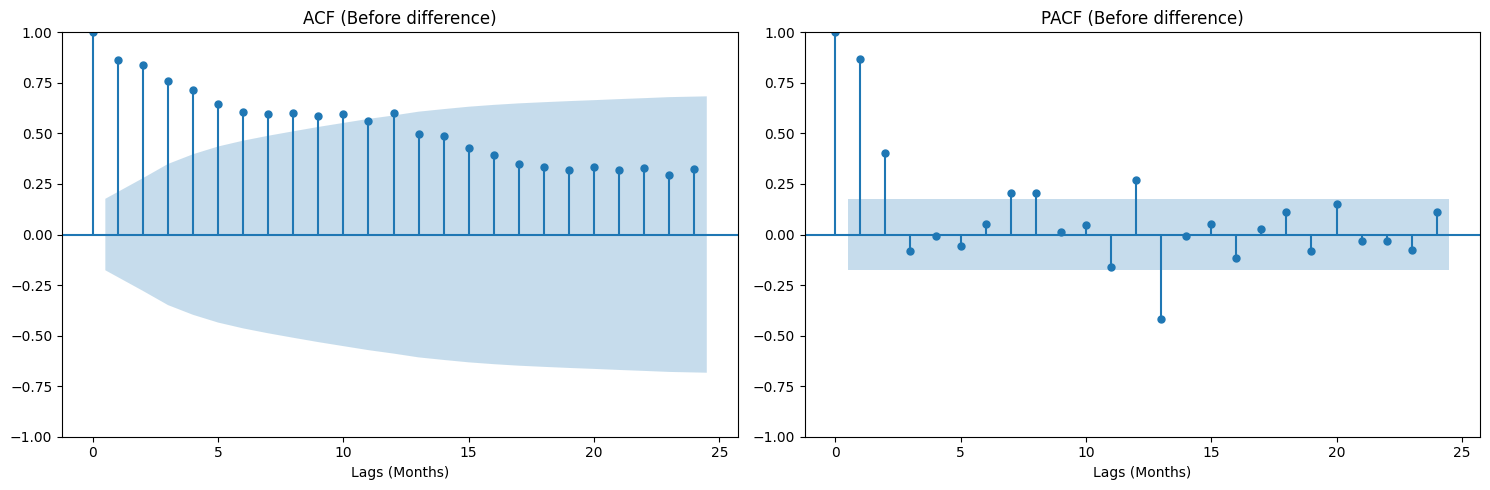

In [ ]:
# Գծում ենք ACF և PACF հին `ln_Transfers_Russia` շարքի համար (մինչև .diff() անելը)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Հին շարքի ACF
plot_acf(model_df['ln_Transfers_Russia'].dropna(), lags=24, ax=axes[0])
axes[0].set_title("ACF (Before difference)")
axes[0].set_xlabel("Lags (Months)")

# 2. Հին շարքի PACF
plot_pacf(model_df['ln_Transfers_Russia'].dropna(), lags=24, ax=axes[1], method='yw')
axes[1].set_title("PACF (Before difference)")
axes[1].set_xlabel("Lags (Months)")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Ստեղծում ենք նոր DataFrame տարբերությունների համար
diff_df = pd.DataFrame(index=model_df.index)

# 2. Հաշվում ենք առաջին տարբերությունները (.diff() ֆունկցիայով)
diff_df['d_ln_Loans'] = model_df['ln_Loans'].diff()
diff_df['d_ln_Transfers_Russia'] = model_df['ln_Transfers_Russia'].diff()
diff_df['d_ln_Transfers_Rest'] = model_df['ln_Transfers_Rest'].diff()
diff_df['d_ln_FX_USD_AMD'] = model_df['ln_FX_USD_AMD'].diff()

# 3. Դամմի փոփոխականները չեն տարբերակվում, դրանք ուղղակի տեղափոխում ենք
diff_df['Crisis_2022'] = model_df['Crisis_2022']
diff_df['Covid_2020'] = model_df['Covid_2020']

# 4. Ջնջում ենք ամենաառաջին տողը (2016-01-01), քանի որ դրա համար հետադարձ տող չկա և դարձել է NaN
diff_df.dropna(inplace=True)

print(diff_df.head(3))

print("\n" + "="*40 + "\n")

# 5. Վազեցնում ենք ADF թեստը արդեն աճի տեմպերի (d_) համար
diff_columns = ['d_ln_Loans', 'd_ln_Transfers_Russia', 'd_ln_Transfers_Rest', 'd_ln_FX_USD_AMD']
for col in diff_columns:
    run_adf_test(diff_df[col], col)

            d_ln_Loans  d_ln_Transfers_Russia  d_ln_Transfers_Rest  \
Date                                                                 
2016-02-01    0.022459               0.352981             0.660674   
2016-03-01   -0.001150               0.252802            -0.181800   
2016-04-01    0.004717               0.036709            -0.148506   

            d_ln_FX_USD_AMD  Crisis_2022  Covid_2020  
Date                                                  
2016-02-01         0.015516            0           0  
2016-03-01        -0.014919            0           0  
2016-04-01        -0.010459            0           0  


=== ADF Test for: d_ln_Loans ===
ADF Statistic: -2.8909
p-value: 0.0464
Critical Values:
	1%: -3.4870
	5%: -2.8864
	10%: -2.5800
 Result: d_ln_Loans-ը is stational (Reject H0)

=== ADF Test for: d_ln_Transfers_Russia ===
ADF Statistic: -2.8607
p-value: 0.0501
Critical Values:
	1%: -3.4912
	5%: -2.8882
	10%: -2.5810
 Result: d_ln_Transfers_Russia-ը is not stational (Fail

In [ ]:
# 1. Տեսնում ենք սկզբնական աղյուսակի չափսերը
print("Սկզբնական աղյուսակի (տողեր, սյուներ)՝", model_df.shape)

# 2. Տեսնում ենք աճի տեմպերի (տարբերությունների) աղյուսակի չափսերը
print("Տարբերակված աղյուսակի (տողեր, սյուներ)՝", diff_df.shape)

Սկզբնական աղյուսակի (տողեր, սյուներ)՝ (123, 6)
Տարբերակված աղյուսակի (տողեր, սյուներ)՝ (122, 6)


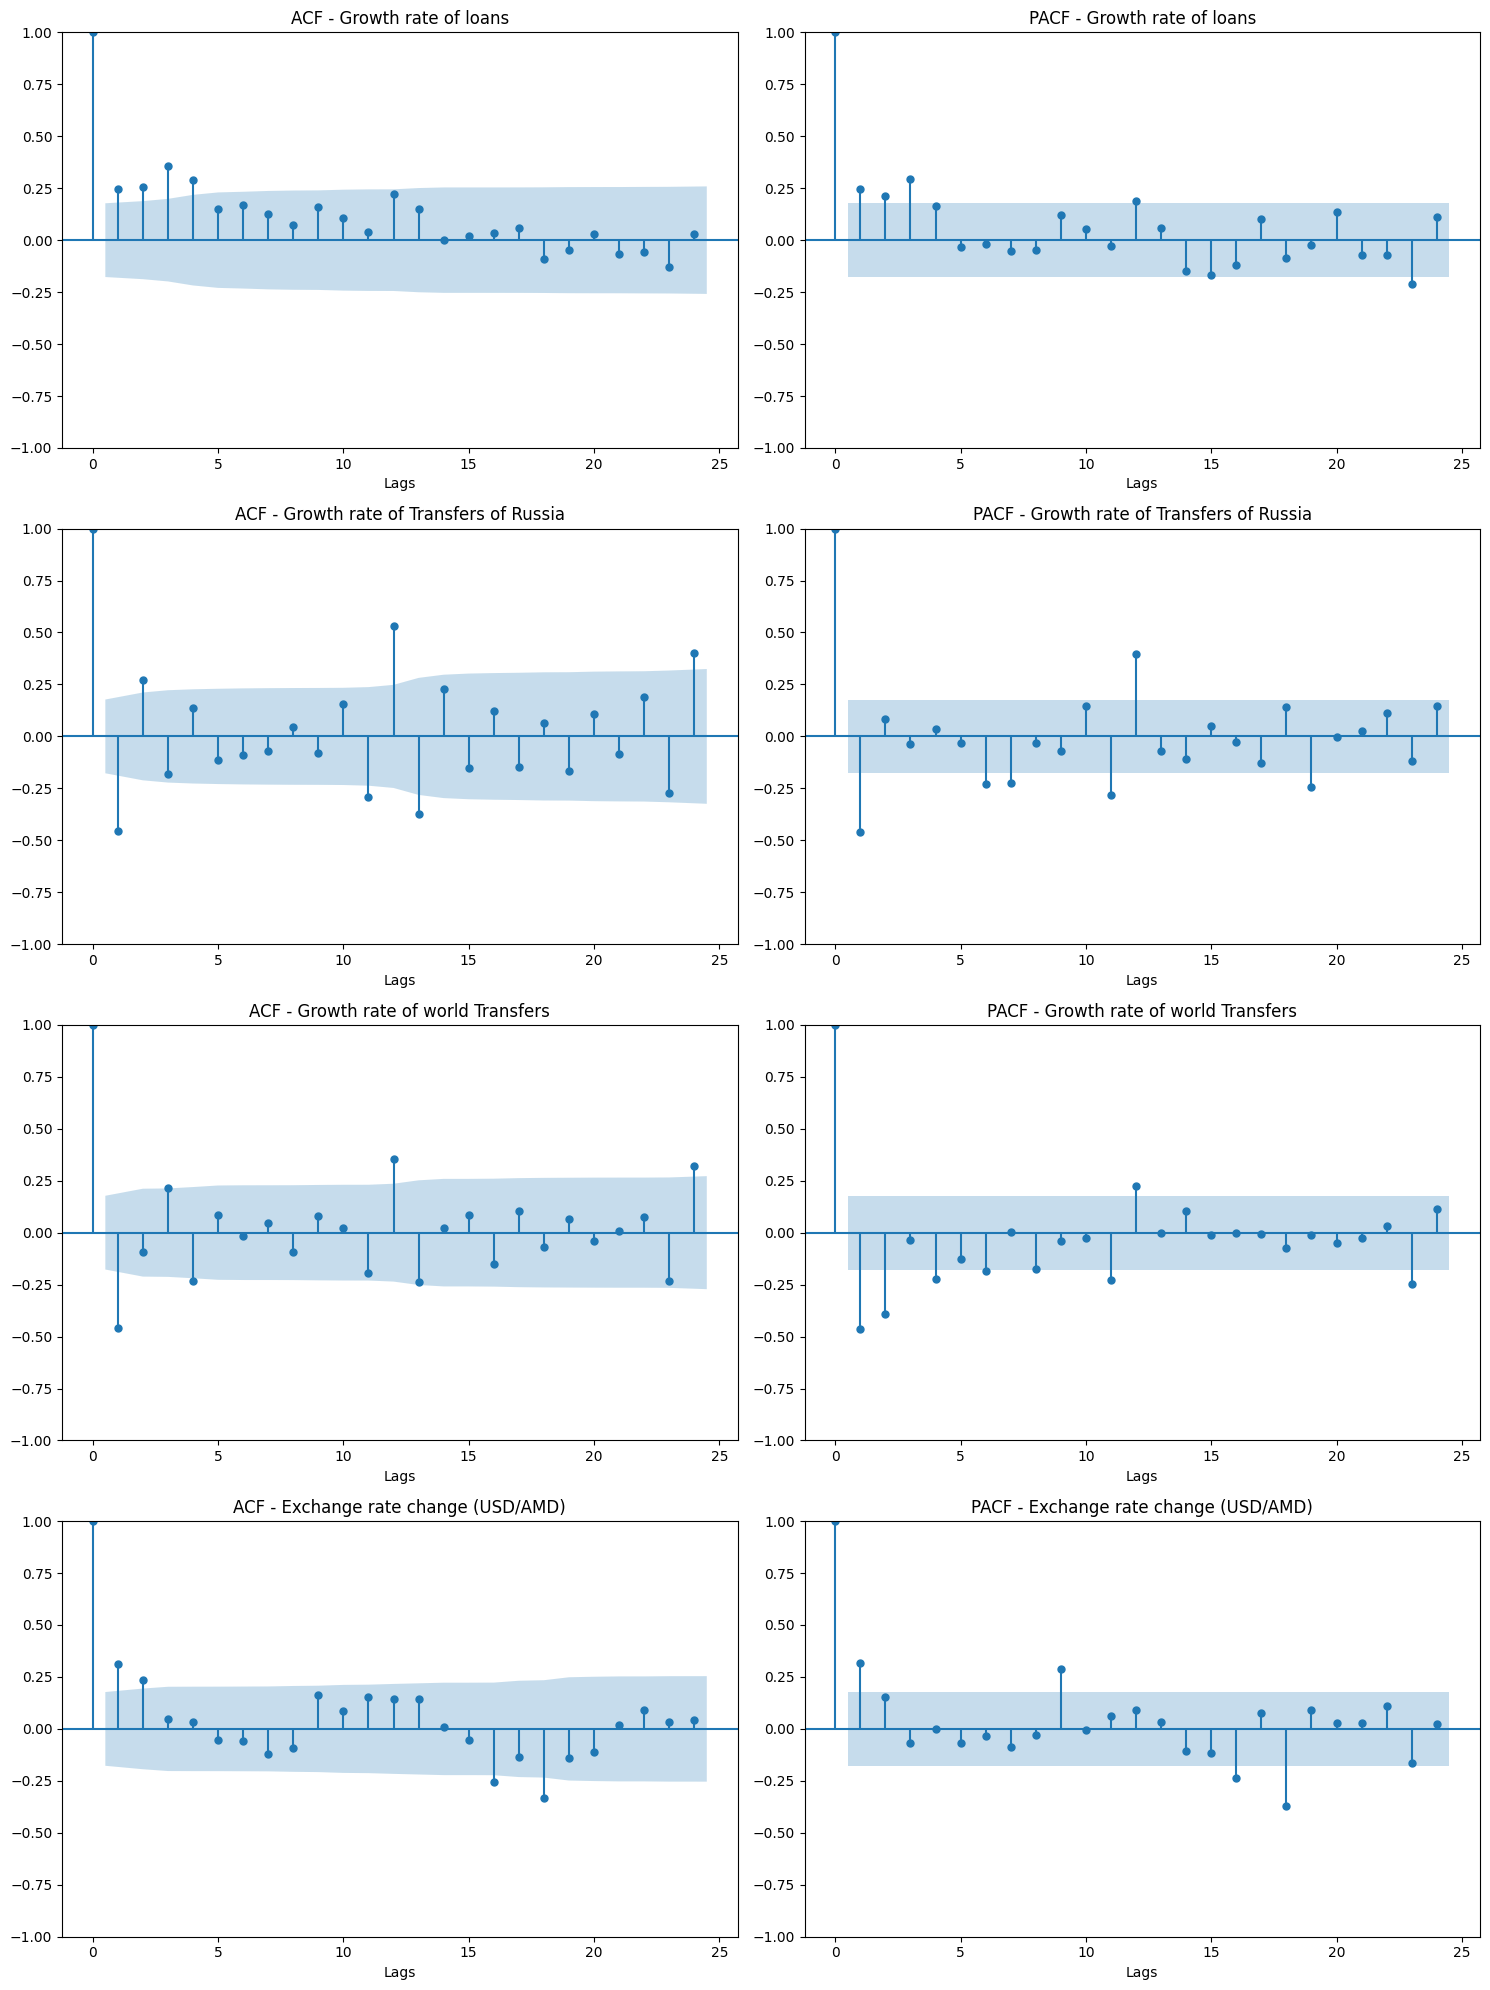

In [ ]:
# Ստեղծում ենք մեծ կտավ՝ 4 տողով և 2 սյունակով (ընդհանուր 8 գրաֆիկ)
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

# Փոփոխականների ցուցակը և իրենց սիրուն անունները գրաֆիկների համար
columns = {
    'd_ln_Loans': 'Growth rate of loans',
    'd_ln_Transfers_Russia': 'Growth rate of Transfers of Russia',
    'd_ln_Transfers_Rest': 'Growth rate of world Transfers',
    'd_ln_FX_USD_AMD': 'Exchange rate change (USD/AMD)'
}

# Ցիկլով անցնում ենք ամեն սյունակի վրայով ու գծում իր շարքը
for i, (col, title_name) in enumerate(columns.items()):
    # Ձախ սյունակ (ACF)
    plot_acf(diff_df[col], lags=24, ax=axes[i, 0])
    axes[i, 0].set_title(f"ACF - {title_name}")
    axes[i, 0].set_xlabel("Lags")

    # Աջ սյունակ (PACF)
    plot_pacf(diff_df[col], lags=24, ax=axes[i, 1], method='yw')
    axes[i, 1].set_title(f"PACF - {title_name}")
    axes[i, 1].set_xlabel("Lags")

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.api import VAR

# 1. Առանձնացնում ենք էնդոգեն (ներքին) փոփոխականները
endog_cols = ['d_ln_Loans', 'd_ln_Transfers_Russia', 'd_ln_Transfers_Rest', 'd_ln_FX_USD_AMD']
endog_data = diff_df[endog_cols].dropna()

# 2. Առանձնացնում ենք էկզոգեն (արտաքին) շոկերը (Դամմիները)
exog_cols = ['Crisis_2022', 'Covid_2020']
exog_data = diff_df.loc[endog_data.index, exog_cols]

# 3. Ստեղծում ենք VAR մոդելի օբյեկտը
model = VAR(endog_data, exog=exog_data)

# 4. Փնտրում ենք օպտիմալ լագը մինչև 12 ամսվա խորությամբ
lag_order = model.select_order(maxlags=12)

# 5. Տպում ենք արդյունքների հաշվետվությունը
print("LAG SELECTION CRITERIA):")
print(lag_order.summary())

LAG SELECTION CRITERIA):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -23.41      -23.12   6.794e-11      -23.29
1       -23.91     -23.22*   4.143e-11      -23.63
2       -24.10      -23.02   3.439e-11     -23.66*
3      -24.20*      -22.72  3.122e-11*      -23.60
4       -24.14      -22.27   3.344e-11      -23.38
5       -23.94      -21.68   4.120e-11      -23.02
6       -23.91      -21.26   4.315e-11      -22.83
7       -23.76      -20.72   5.099e-11      -22.53
8       -23.74      -20.30   5.379e-11      -22.34
9       -23.70      -19.87   5.786e-11      -22.15
10      -23.80      -19.58   5.484e-11      -22.09
11      -23.92      -19.30   5.173e-11      -22.05
12      -24.07      -19.06   4.768e-11      -22.04
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# ================================
# VARX(3) MODEL ESTIMATION
# ================================

selected_lag = 3
varx_results = model.fit(selected_lag)

print(varx_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 27, May, 2026
Time:                     10:11:27
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -22.7167
Nobs:                     119.000    HQIC:                  -23.5490
Log likelihood:           819.605    FPE:                3.37314e-11
AIC:                     -24.1180    Det(Omega_mle):     2.09799e-11
--------------------------------------------------------------------
Results for equation d_ln_Loans
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                            0.002163         0.001867            1.159           0.247
Crisis_2022                      0.000195         0.002434            0.080           0.936
Covid_2020 

In [ ]:
# ================================
# RESIDUAL AUTOCORRELATION TEST
# Portmanteau / Whiteness test
# ================================

white_test = varx_results.test_whiteness(nlags=12, adjusted=True)

print(white_test.summary())

print("\nPortmanteau test p-value:", white_test.pvalue)

if white_test.pvalue > 0.05:
    print("Result: Residuals are white noise. No autocorrelation detected.")
else:
    print("Result: Residuals are NOT white noise. Autocorrelation remains.")

Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         174.5          173.0   0.042 144
-----------------------------------------

Portmanteau test p-value: 0.04237545118086843
Result: Residuals are NOT white noise. Autocorrelation remains.


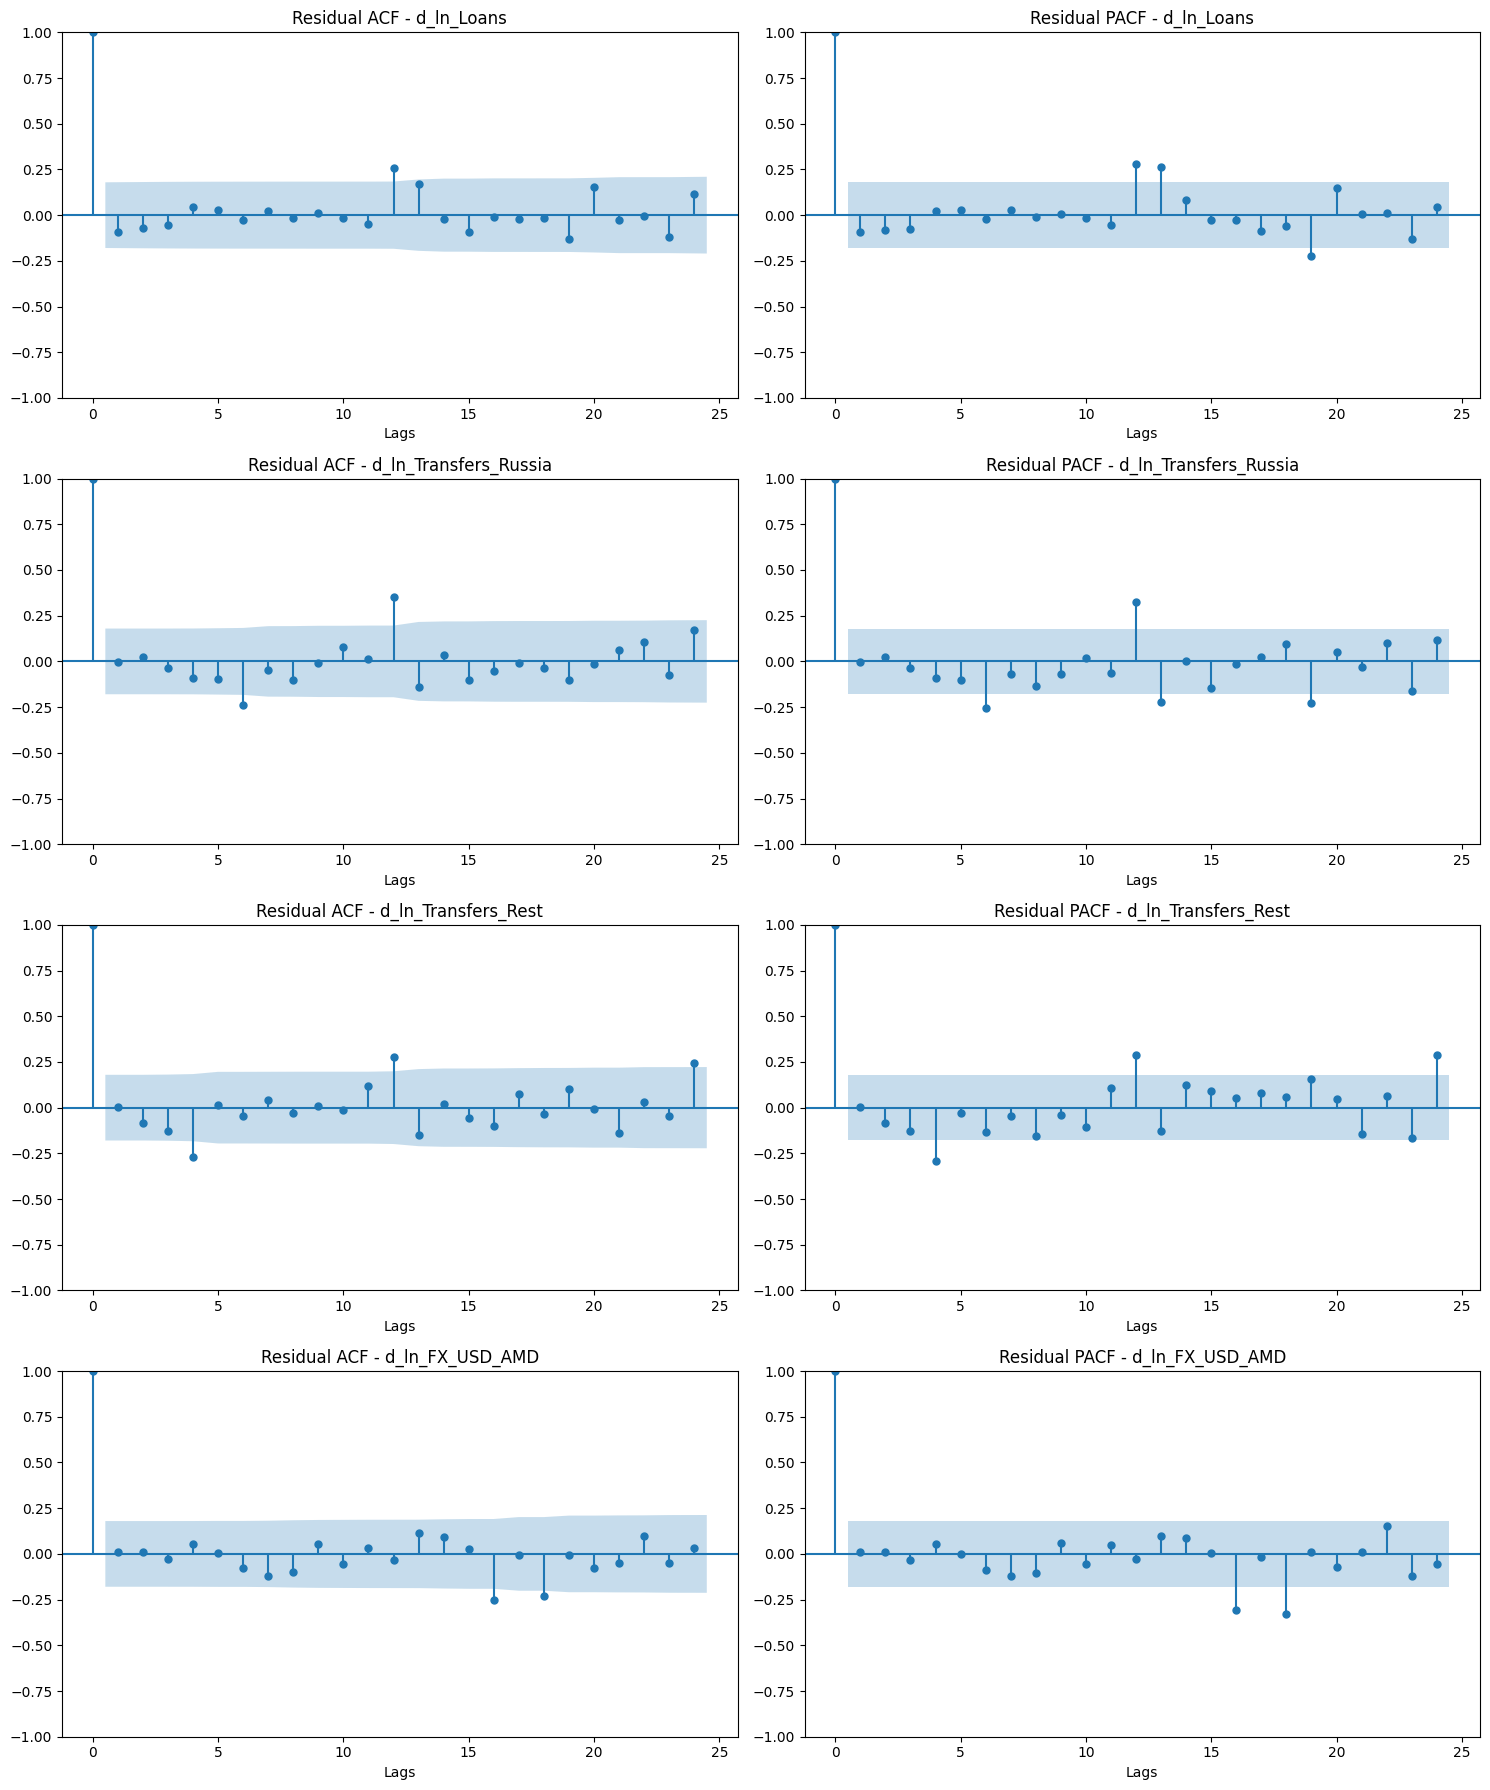

In [ ]:
# ================================
# RESIDUAL ACF/PACF PLOTS
# ================================

residuals = varx_results.resid

fig, axes = plt.subplots(len(residuals.columns), 2, figsize=(15, 18))

for i, col in enumerate(residuals.columns):
    plot_acf(residuals[col], lags=24, ax=axes[i, 0])
    axes[i, 0].set_title(f"Residual ACF - {col}")
    axes[i, 0].set_xlabel("Lags")

    plot_pacf(residuals[col], lags=24, ax=axes[i, 1], method='yw')
    axes[i, 1].set_title(f"Residual PACF - {col}")
    axes[i, 1].set_xlabel("Lags")

plt.tight_layout()
plt.show()

In [ ]:
# ================================
# STABILITY TEST
# ================================

print("Is the VARX(3) model stable?")
print(varx_results.is_stable(verbose=True))

roots = varx_results.roots
root_modulus = np.abs(roots)

stability_table = pd.DataFrame({
    "Root": roots,
    "Modulus": root_modulus
})

print(stability_table)

if np.all(root_modulus > 1):
    print("Result: The model is stable according to statsmodels roots condition.")
else:
    print("Result: The model is NOT stable.")

Is the VARX(3) model stable?
Eigenvalues of VAR(1) rep
0.8049624004771934
0.570452205099771
0.570452205099771
0.6777353674509303
0.6777353674509303
0.4869344275602732
0.4869344275602732
0.6485849947187499
0.6485849947187499
0.06539105778846543
0.7561491429088402
0.6113003146000151
True
                    Root    Modulus
0  -15.292611- 0.000000j  15.292611
1    0.208466+ 2.043057j   2.053665
2    0.208466- 2.043057j   2.053665
3    1.472125- 0.951756j   1.752995
4    1.472125+ 0.951756j   1.752995
5   -1.635857- 0.000000j   1.635857
6   -0.985116- 1.186064j   1.541818
7   -0.985116+ 1.186064j   1.541818
8   -0.498168- 1.388861j   1.475502
9   -0.498168+ 1.388861j   1.475502
10  -1.322490- 0.000000j   1.322490
11   1.242294- 0.000000j   1.242294
Result: The model is stable according to statsmodels roots condition.


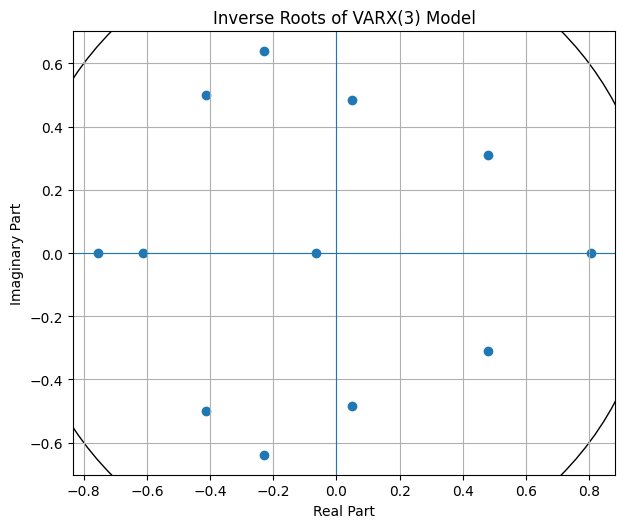

All inverse roots are inside the unit circle: model is stable.


In [ ]:
# ================================
# INVERSE ROOTS PLOT
# ================================

inverse_roots = 1 / roots

fig, ax = plt.subplots(figsize=(7, 7))

# Unit circle
circle = plt.Circle((0, 0), 1, fill=False)
ax.add_artist(circle)

ax.scatter(inverse_roots.real, inverse_roots.imag)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_title("Inverse Roots of VARX(3) Model")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")

ax.set_aspect("equal", adjustable="box")
ax.grid(True)
plt.show()

if np.all(np.abs(inverse_roots) < 1):
    print("All inverse roots are inside the unit circle: model is stable.")
else:
    print("Some inverse roots are outside the unit circle: model may be unstable.")

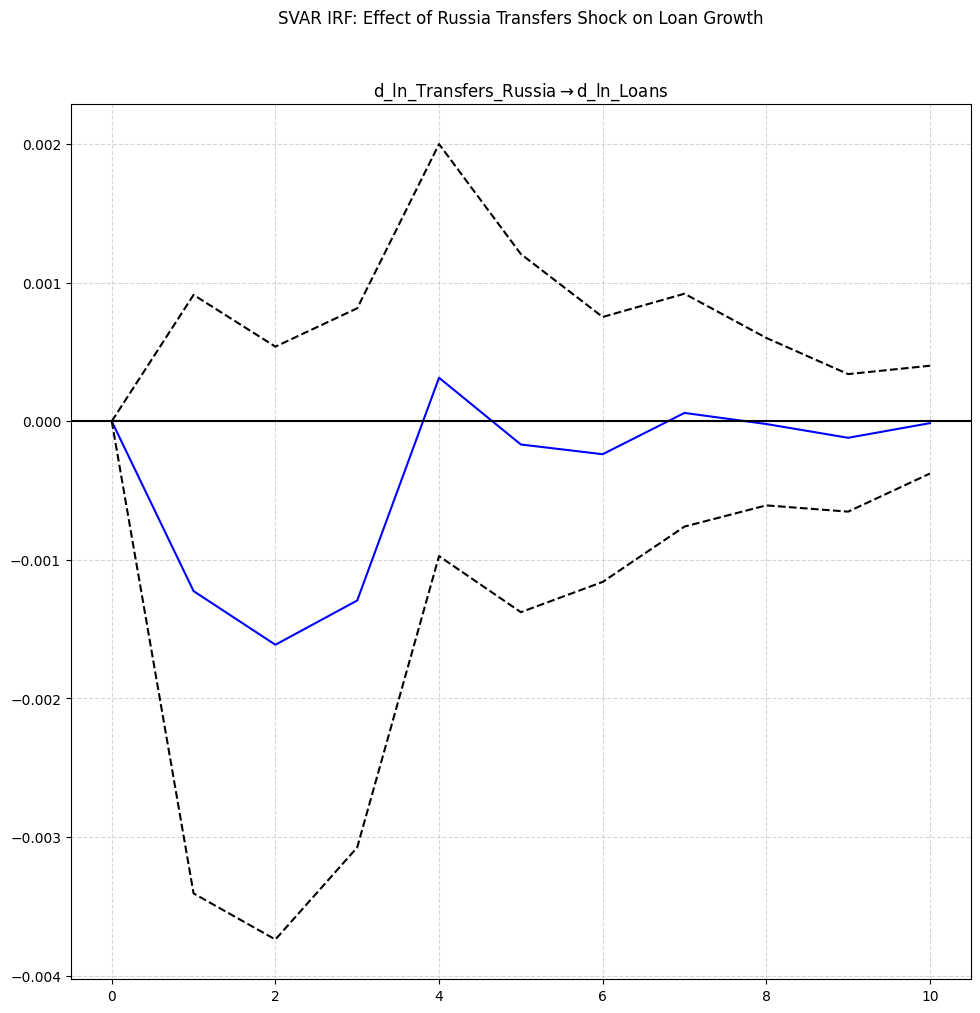

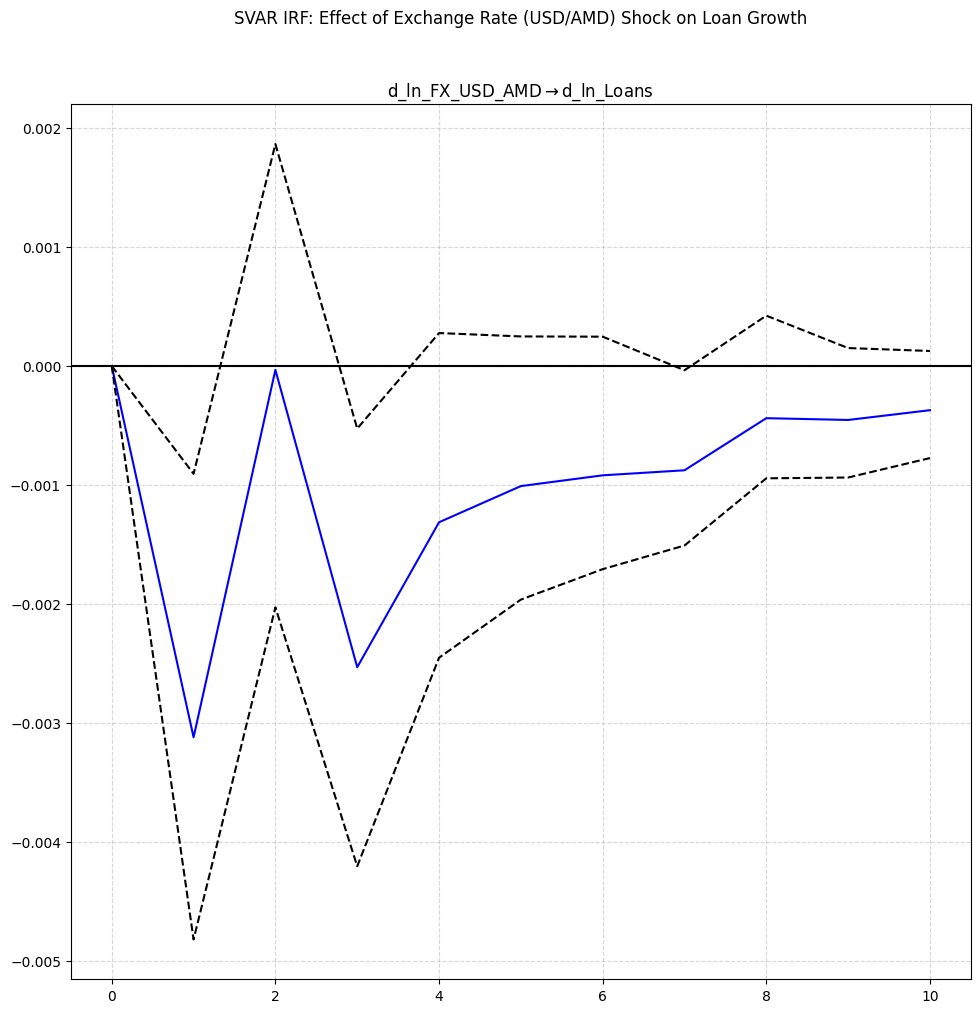

In [ ]:
import matplotlib.pyplot as plt

# 1. Create IRF object for 10 periods (months)
irf = varx_results.irf(periods=10)

# ==============================================================================
# PLOT 1: Effect of Russia Transfers Shock on Loan Growth
# ==============================================================================
fig1 = irf.plot(orth=True,
                impulse='d_ln_Transfers_Russia',
                response='d_ln_Loans',
                signif=0.05,
                stderr_type='mc')

plt.suptitle('SVAR IRF: Effect of Russia Transfers Shock on Loan Growth', fontsize=12, y=1.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# PLOT 2: Effect of Exchange Rate (USD/AMD) Shock on Loan Growth
# ==============================================================================
fig2 = irf.plot(orth=True,
                impulse='d_ln_FX_USD_AMD',  # Impulse is changed to exchange rate
                response='d_ln_Loans',      # Response remains loan growth
                signif=0.05,
                stderr_type='mc')

plt.suptitle('SVAR IRF: Effect of Exchange Rate (USD/AMD) Shock on Loan Growth', fontsize=12, y=1.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


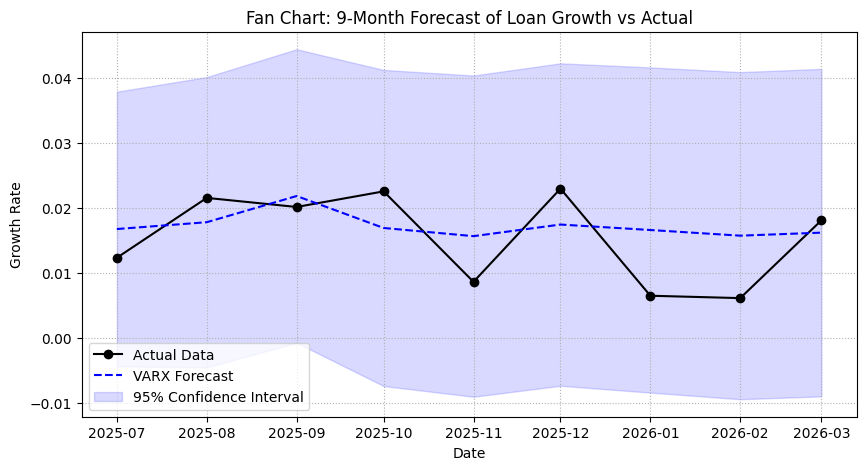

In [ ]:
# 1. Train/Test split (keep the last 9 months for testing)
test_len = 9
train_endog = endog_data.iloc[:-test_len]
train_exog = exog_data.iloc[:-test_len]
test_endog = endog_data.iloc[-test_len:]
test_exog = exog_data.iloc[-test_len:]

# 2. Re-estimate the VARX model on the Train set
model_train = VAR(train_endog, exog=train_exog)
varx_train_res = model_train.fit(3)

# 3. Generate 9-month forecast with confidence intervals
fc_mid, fc_lower, fc_upper = varx_train_res.forecast_interval(
    train_endog.values[-3:],
    steps=test_len,
    exog_future=test_exog.values,
    alpha=0.05
)

# 4. Plot Fan Chart for 'd_ln_Loans' (index 0)
plt.figure(figsize=(10, 5))
plt.plot(test_endog.index, test_endog['d_ln_Loans'], color='black', marker='o', label='Actual Data')
plt.plot(test_endog.index, fc_mid[:, 0], color='blue', linestyle='--', label='VARX Forecast')
plt.fill_between(test_endog.index, fc_lower[:, 0], fc_upper[:, 0], color='blue', alpha=0.15, label='95% Confidence Interval')

plt.title('Fan Chart: 9-Month Forecast of Loan Growth vs Actual')
plt.xlabel('Date')
plt.ylabel('Growth Rate')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Feature Engineering: Create lags for Machine Learning
ml_features = pd.DataFrame(index=endog_data.index)
for col in endog_data.columns:
    for lag in range(1, 4):
        ml_features[f'{col}_lag_{lag}'] = endog_data[col].shift(lag)

# Combine target (Loans), lags, and exogenous dummies
ml_df = pd.concat([endog_data['d_ln_Loans'], ml_features, exog_data], axis=1).dropna()

# 2. Train / Test Split (exactly the same last 9 months)
train_ml = ml_df.iloc[:-test_len]
test_ml = ml_df.iloc[-test_len:]

X_train = train_ml.drop(columns=['d_ln_Loans'])
y_train = train_ml['d_ln_Loans']
X_test = test_ml.drop(columns=['d_ln_Loans'])
y_test = test_ml['d_ln_Loans']

# 3. Train and forecast using Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 4. Calculate RMSE for both models
varx_rmse = np.sqrt(mean_squared_error(y_test, fc_mid[:, 0]))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"=== FORECAST QUALITY COMPARISON (RMSE) ===")
print(f"Econometric VARX Model RMSE: {varx_rmse:.6f}")
print(f"Machine Learning (Random Forest) RMSE: {rf_rmse:.6f}")

=== FORECAST QUALITY COMPARISON (RMSE) ===
Econometric VARX Model RMSE: 0.006201
Machine Learning (Random Forest) RMSE: 0.008647
